In [2]:
# Simple Linear Regression for predicting the house price based on size of the house
import numpy as np
import matplotlib.pyplot as plt

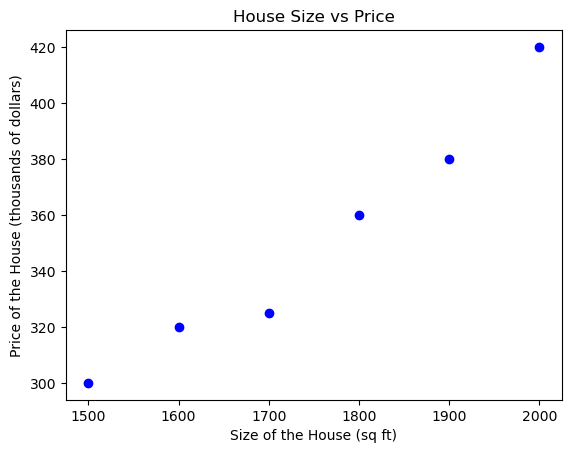

In [ ]:
# Generating synthetic data for house sizes (in square feet) and their corresponding prices (in thousands of dollars)
house_sizes = np.array([1500, 1600, 1700, 1800, 1900, 2000])
house_prices = np.array([300, 320, 325, 360, 380, 420])

# Visualizing the data
plt.scatter(house_sizes, house_prices, color='blue')
plt.title('House Size vs Price')
plt.xlabel('Size of the House (sq ft)')
plt.ylabel('Price of the House (thousands of dollars)')
plt.show()

In [8]:
# Training a simple linear regression model
from sklearn.linear_model import LinearRegression
# Reshaping the data for sklearn
house_sizes = house_sizes.reshape(-1, 1) # transforming to 2D array
model = LinearRegression()
model.fit(house_sizes, house_prices)

# Predicting the price of a house with size 1850 sq ft
predicted_price = model.predict([[1850]])
print(f"The predicted price of a house with size 1850 sq ft is: {predicted_price[0]:.2f} thousand dollars")

The predicted price of a house with size 1850 sq ft is: 374.12 thousand dollars


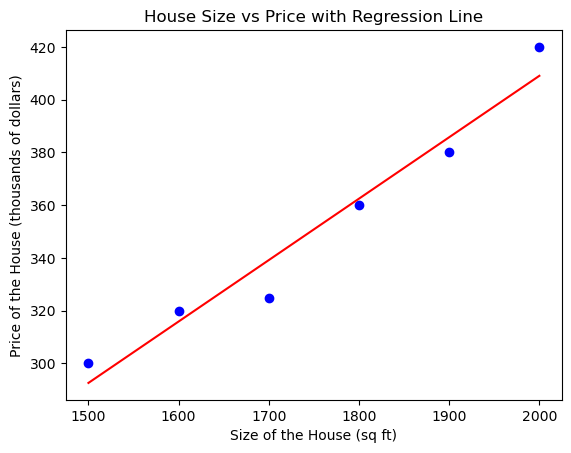

In [9]:
# Visualizing the regression line
plt.scatter(house_sizes, house_prices, color='blue')
plt.plot(house_sizes, model.predict(house_sizes), color='red') # regression line
plt.title('House Size vs Price with Regression Line')
plt.xlabel('Size of the House (sq ft)')
plt.ylabel('Price of the House (thousands of dollars)')
plt.show()

In [ ]:
# Accuracy of the model
from sklearn.metrics import r2_score
predicted_prices = model.predict(house_sizes)
accuracy = r2_score(house_prices, predicted_prices)
print(f"R-squared value (accuracy) of the model: {accuracy:.2f}")

# calculating the mean squared error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(house_prices, predicted_prices)
print(f"Mean Squared Error of the model: {mse:.2f}")

R-squared value (accuracy) of the model: 0.96
Mean Squared Error of the model: 71.98


Multiple features Linear Regression Model

In [ ]:
# Adding more features to the dataset (number of bedrooms and age of the house)
house_sizes = np.array([1500, 1600, 1700, 1800, 1900, 2000])
number_of_bedrooms = np.array([3, 3, 4, 4, 5, 5])
age_of_house = np.array([10, 8, 6, 4, 2, 1])
house_prices = np.array([300, 320, 325, 360, 380, 420])

# Combining the features into a single dataset
features = np.column_stack((house_sizes, number_of_bedrooms, age_of_house))

features

array([[1500,    3,   10],
       [1600,    3,    8],
       [1700,    4,    6],
       [1800,    4,    4],
       [1900,    5,    2],
       [2000,    5,    1]])

In [11]:
# Performing EDA on the new dataset
import pandas as pd
data = pd.DataFrame(features, columns=['Size', 'Bedrooms', 'Age'])
data['Price'] = house_prices
print(data.describe())


              Size  Bedrooms        Age       Price
count     6.000000  6.000000   6.000000    6.000000
mean   1750.000000  4.000000   5.166667  350.833333
std     187.082869  0.894427   3.488075   44.543986
min    1500.000000  3.000000   1.000000  300.000000
25%    1625.000000  3.250000   2.500000  321.250000
50%    1750.000000  4.000000   5.000000  342.500000
75%    1875.000000  4.750000   7.500000  375.000000
max    2000.000000  5.000000  10.000000  420.000000


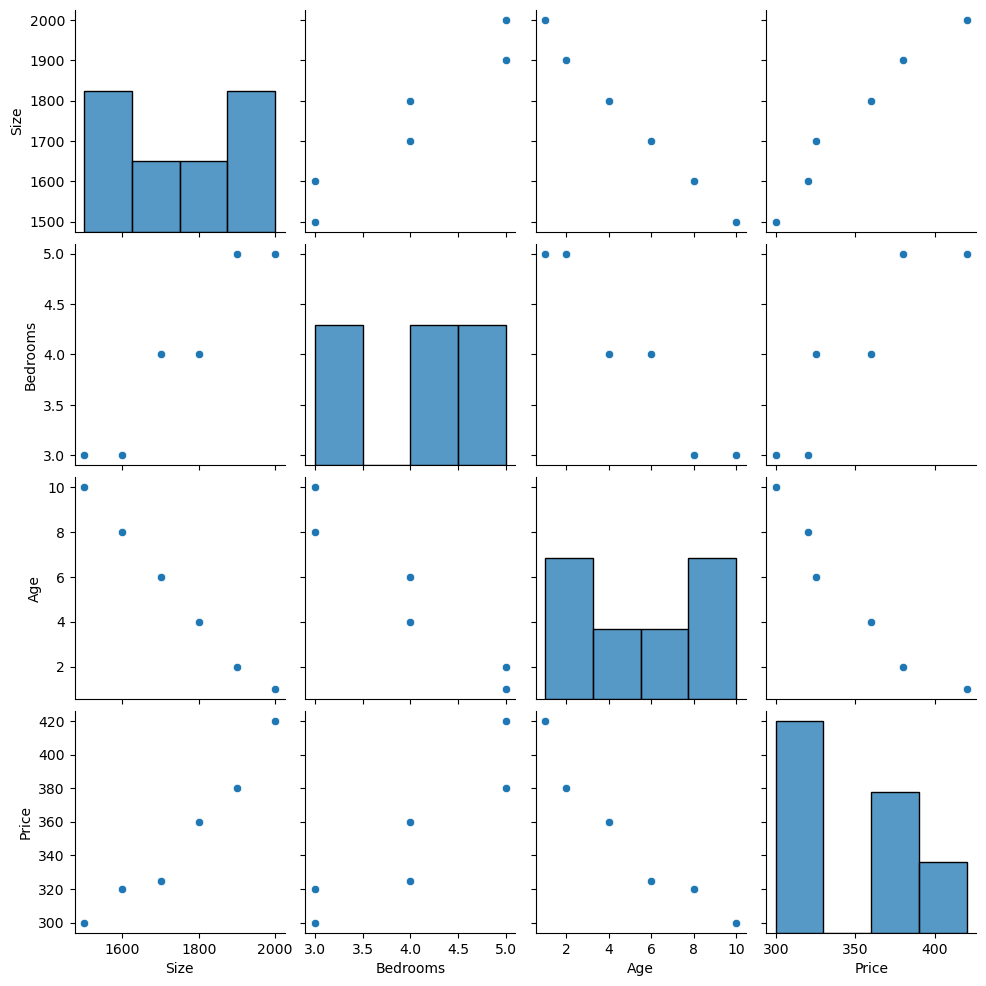

In [ ]:
# More detailed EDA with pairplot
import seaborn as sns
sns.pairplot(data) # This will show pairwise relationships in the dataset
plt.show()

In [5]:
# Training the linear regression model with multiple features
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(features, house_prices)
# Predicting the price of a house with size 1850 sq ft, 4 bedrooms, and age of 5 years
predicted_price = model.predict([[1850, 4, 5]])
print(f"The predicted price of a house with size 1850 sq ft, 4 bedrooms, and age of 5 years is: {predicted_price[0]:.2f} thousand dollars")


The predicted price of a house with size 1850 sq ft, 4 bedrooms, and age of 5 years is: 412.50 thousand dollars


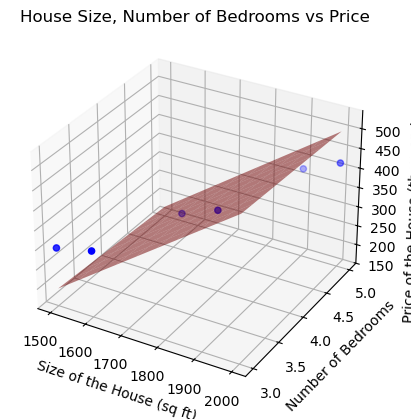

In [6]:
#Visualizing the regression plane for the first two features (house size and number of bedrooms)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(features[:, 0], features[:, 1], house_prices, color='blue')

# Creating a grid of values for the first two features
house_size_range = np.linspace(1500, 2000, 10)
bedroom_range = np.linspace(3, 5, 10)
house_size_grid, bedroom_grid = np.meshgrid(house_size_range, bedroom_range)
# Predicting the prices for the grid of values
price_grid = model.predict(np.column_stack((house_size_grid.ravel(), bedroom_grid.ravel(), np.full(house_size_grid.ravel().shape, 5))))
price_grid = price_grid.reshape(house_size_grid.shape)
# Plotting the regression plane
ax.plot_surface(house_size_grid, bedroom_grid, price_grid, color='red', alpha=0.5)
ax.set_title('House Size, Number of Bedrooms vs Price')
ax.set_xlabel('Size of the House (sq ft)')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('Price of the House (thousands of dollars)')
plt.show()

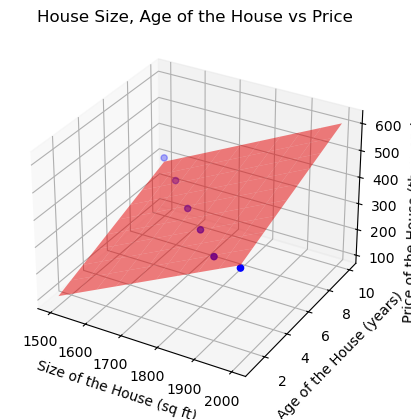

In [13]:
# visualizing the regression plane for the first and third features (house size and age of the house)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(features[:, 0], features[:, 2], house_prices, color='blue')
# Creating a grid of values for the first and third features
house_size_range = np.linspace(1500, 2000, 10)
age_range = np.linspace(1, 10, 10)
house_size_grid, age_grid = np.meshgrid(house_size_range, age_range)
# Predicting the prices for the grid of values
price_grid = model.predict(np.column_stack((house_size_grid.ravel(), np.full(house_size_grid.ravel().shape, 4), age_grid.ravel())))
price_grid = price_grid.reshape(house_size_grid.shape)
# Plotting the regression plane
ax.plot_surface(house_size_grid, age_grid, price_grid, color='red', alpha=0.5)
ax.set_title('House Size, Age of the House vs Price')
ax.set_xlabel('Size of the House (sq ft)')
ax.set_ylabel('Age of the House (years)')
ax.set_zlabel('Price of the House (thousands of dollars)')
plt.show()

In [10]:
# Finding accuracy of the model with multiple features and calculating the mean squared error
from sklearn.metrics import r2_score, mean_squared_error
predicted_prices = model.predict(features)
accuracy = r2_score(house_prices, predicted_prices)
print(f"R-squared value (accuracy) of the model with multiple features: {accuracy:.2f}")
mse = mean_squared_error(house_prices, predicted_prices)
print(f"Mean Squared Error of the model with multiple features: {mse:.2f}")

R-squared value (accuracy) of the model with multiple features: 0.98
Mean Squared Error of the model with multiple features: 25.00


In [15]:
# Showing the final regression coefficients for the model with multiple features
print("Regression coefficients for the model with multiple features:")
print(f"Coefficient for house size: {model.coef_[0]:.2f}")
print(f"Coefficient for number of bedrooms: {model.coef_[1]:.2f}")
print(f"Coefficient for age of the house: {model.coef_[2]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

#printing the final linear regression equation
intercept = model.intercept_
print(f"The final linear regression equation is: Price = {intercept:.2f} + ({model.coef_[0]:.2f} * Size) + ({model.coef_[1]:.2f} * Bedrooms) + ({model.coef_[2]:.2f} * Age)")



Regression coefficients for the model with multiple features:
Coefficient for house size: 0.65
Coefficient for number of bedrooms: -10.00
Coefficient for age of the house: 20.00
Intercept: -850.00
The final linear regression equation is: Price = -850.00 + (0.65 * Size) + (-10.00 * Bedrooms) + (20.00 * Age)


In [16]:
# understanding the feature importance by looking at the absolute values of the coefficients
feature_importance = np.abs(model.coef_)
feature_names = ['Size', 'Bedrooms', 'Age']
for name, importance in zip(feature_names, feature_importance):
    print(f"Feature: {name}, Importance: {importance:.2f}")
    

Feature: Size, Importance: 0.65
Feature: Bedrooms, Importance: 10.00
Feature: Age, Importance: 20.00


In [17]:
# total error of the model
total_error = np.sum((house_prices - predicted_prices) ** 2)    
print(f"Total Error of the model: {total_error:.2f}")

Total Error of the model: 150.00


In [ ]:
# goodness of fit of the model
goodness_of_fit = 1 - (total_error / np.sum((house_prices - np.mean(house_prices)) ** 2))
print(f"Goodness of Fit of the model: {goodness_of_fit:.2f}")

Goodness of Fit of the model: 0.98
